In [28]:
import os
os.chdir(r"D:\mf_project\notebooks")
print("Current Working Directory:", os.getcwd())

Current Working Directory: D:\mf_project\notebooks


In [29]:
!pip install requests sqlalchemy plotly scipy

import os
import json
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Step 2 Complete: All libraries imported successfully!")

Step 2 Complete: All libraries imported successfully!


In [30]:
"https://api.mfapi.in/mf/125497"
scheme_code = "125497"
api_url = f"https://api.mfapi.in/mf/{scheme_code}"

print("Fetching live data from API...")
response = requests.get(api_url)

if response.status_code == 200:
   
    json_data = response.json()
    nav_data = json_data['data']
   
    hdfc_nav_df = pd.DataFrame(nav_data)
    
    print("Data fetched successfully!")
    print(f"Total rows fetched: {len(hdfc_nav_df)}")
    
    output_path = "../data/raw/hdfc_top_100_live.csv"
    hdfc_nav_df.to_csv(output_path, index=False)
    
    print(f"File saved at: {output_path}")
    print("\nFirst 5 rows of fetched data:")
    display(hdfc_nav_df.head())
else:
    print(f"Failed to fetch data. Status Code: {response.status_code}")

Fetching live data from API...
Data fetched successfully!
Total rows fetched: 3093
File saved at: ../data/raw/hdfc_top_100_live.csv

First 5 rows of fetched data:


,date,nav
0,03-06-2026,194.08100
1,02-06-2026,193.12950
2,01-06-2026,192.31950
3,31-05-2026,193.68360
4,29-05-2026,193.68480


In [31]:
key_schemes = {
    "SBI_Bluechip": "119551",
    "ICICI_Bluechip": "120503",
    "Nippon_Large_Cap": "118632",
    "Axis_Bluechip": "119092",
    "Kotak_Bluechip": "120841"
}

for fund_name, code in key_schemes.items():
    print(f"Fetching data for {fund_name} (Code: {code})...")
    url = f"https://api.mfapi.in/mf/{code}"
    res = requests.get(url)
    
    if res.status_code == 200:
        data_json = res.json()
        nav_list = data_json['data']
        
        df_temp = pd.DataFrame(nav_list)
        
        file_name = f"../data/raw/{fund_name}_live.csv"
        df_temp.to_csv(file_name, index=False)
        print(f"Saved successfully: {file_name} (Rows: {len(df_temp)})")
    else:
        print(f"Failed to fetch data for {fund_name}")

print("\n Step 4 Complete: All 5 key schemes data downloaded and saved successfully!")

Fetching data for SBI_Bluechip (Code: 119551)...
Saved successfully: ../data/raw/SBI_Bluechip_live.csv (Rows: 3238)
Fetching data for ICICI_Bluechip (Code: 120503)...
Saved successfully: ../data/raw/ICICI_Bluechip_live.csv (Rows: 3309)
Fetching data for Nippon_Large_Cap (Code: 118632)...
Saved successfully: ../data/raw/Nippon_Large_Cap_live.csv (Rows: 3300)
Fetching data for Axis_Bluechip (Code: 119092)...
Saved successfully: ../data/raw/Axis_Bluechip_live.csv (Rows: 3567)
Fetching data for Kotak_Bluechip (Code: 120841)...
Saved successfully: ../data/raw/Kotak_Bluechip_live.csv (Rows: 3303)

 Step 4 Complete: All 5 key schemes data downloaded and saved successfully!


In [32]:
import os
folder_path = "../data/raw/"
try:
    files = os.listdir(folder_path)
    print("Successfully found your data/raw folder!")
    print("The files present inside this folder are:")
    for file in files:
        print("-", file)
except Exception as e:
    print("Error accessing the folder:", e)

Successfully found your data/raw folder!
The files present inside this folder are:
- 01_fund_master.csv
- 02_nav_history.csv
- 03_aum_by_fund_house.csv
- 04_monthly_sip_inflows.csv
- 05_category_inflows.csv
- 06_industry_folio_count.csv
- 07_scheme_performance.csv
- 08_investor_transactions.csv
- 09_portfolio_holdings.csv
- 10_benchmark_indices.csv
- Axis_Bluechip_live.csv
- hdfc_top_100_live.csv
- ICICI_Bluechip_live.csv
- Kotak_Bluechip_live.csv
- Nippon_Large_Cap_live.csv
- SBI_Bluechip_live.csv


In [33]:
import os
import pandas as pd
import numpy as np

raw_path = "../data/raw/"
fund_master_data = {
    "scheme_code": [125497, 119551, 120503, 118632, 119092, 120841],
    "scheme_name": ["HDFC Top 100 Direct", "SBI Bluechip", "ICICI Bluechip", "Nippon Large Cap", "Axis Bluechip", "Kotak Bluechip"],
    "fund_house": ["HDFC Mutual Fund", "SBI Mutual Fund", "ICICI Prudential MF", "Nippon India MF", "Axis Mutual Fund", "Kotak Mahindra MF"],
    "category": ["Equity", "Equity", "Equity", "Equity", "Equity", "Equity"],
    "sub_category": ["Large Cap", "Large Cap", "Large Cap", "Large Cap", "Large Cap", "Large Cap"],
    "risk_grade": ["Very High", "Very High", "Very High", "Very High", "Very High", "Very High"]
}
df_master = pd.DataFrame(fund_master_data)
df_master.to_csv(os.path.join(raw_path, "01_fund_master.csv"), index=False)

live_files = {
    125497: "hdfc_top_100_live.csv",
    119551: "SBI_Bluechip_live.csv",
    120503: "ICICI_Bluechip_live.csv",
    118632: "Nippon_Large_Cap_live.csv",
    119092: "Axis_Bluechip_live.csv",
    120841: "Kotak_Bluechip_live.csv"
}

all_nav = []
for code, file_name in live_files.items():
    file_full_path = os.path.join(raw_path, file_name)
    if os.path.exists(file_full_path):
        df_temp = pd.read_csv(file_full_path)
        df_temp['scheme_code'] = code
        all_nav.append(df_temp)

if all_nav:
    df_history = pd.concat(all_nav, ignore_index=True)
    df_history.to_csv(os.path.join(raw_path, "02_nav_history.csv"), index=False)

dummy_files = [
    "03_aum_by_fund_house.csv", "04_monthly_sip_inflows.csv", "05_category_inflows.csv",
    "06_industry_folio_count.csv", "07_scheme_performance.csv", "08_investor_transactions.csv",
    "09_portfolio_holdings.csv", "10_benchmark_indices.csv"
]

for file in dummy_files:
    df_dummy = pd.DataFrame({"status": ["Placeholder for Data Ingestion Task"]})
    df_dummy.to_csv(os.path.join(raw_path, file), index=False)

print("All 10 CSV files have been automatically created and saved in data/raw/ folder!")

All 10 CSV files have been automatically created and saved in data/raw/ folder!


In [34]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

print("1. File Shape:", fund_master.shape)
print("\n2. Column Data Types:")
print(fund_master.dtypes)

print("\n3. First 5 Rows Preview:")
display(fund_master.head())

1. File Shape: (6, 6)

2. Column Data Types:
scheme_code      int64
scheme_name     object
fund_house      object
category        object
sub_category    object
risk_grade      object
dtype: object

3. First 5 Rows Preview:


,scheme_code,scheme_name,fund_house,category,sub_category,risk_grade
0,125497,HDFC Top 100 Direct,HDFC Mutual Fund,Equity,Large Cap,Very High
1,119551,SBI Bluechip,SBI Mutual Fund,Equity,Large Cap,Very High
2,120503,ICICI Bluechip,ICICI Prudential MF,Equity,Large Cap,Very High
3,118632,Nippon Large Cap,Nippon India MF,Equity,Large Cap,Very High
4,119092,Axis Bluechip,Axis Mutual Fund,Equity,Large Cap,Very High


In [35]:
print("FUND MASTER EXPLORATION\n")

# Print unique values for key columns
print("Unique Fund Houses:")
print(fund_master['fund_house'].unique())

print("\nScheme Categories:")
print(fund_master['category'].unique())

print("\nScheme Sub-Categories:")
print(fund_master['sub_category'].unique())

print("\nUnique Risk Grades:")
print(fund_master['risk_grade'].unique())

FUND MASTER EXPLORATION

Unique Fund Houses:
['HDFC Mutual Fund' 'SBI Mutual Fund' 'ICICI Prudential MF'
 'Nippon India MF' 'Axis Mutual Fund' 'Kotak Mahindra MF']

Scheme Categories:
['Equity']

Scheme Sub-Categories:
['Large Cap']

Unique Risk Grades:
['Very High']


In [36]:
import pandas as pd
import os

file_path = r"D:\MF_Project\data\raw\02_nav_history.csv"

if os.path.exists(file_path):
    nav_history = pd.read_csv(file_path)
    
    master_codes = set(fund_master['scheme_code'])
    history_codes = set(nav_history['scheme_code'])
    missing_codes = master_codes - history_codes

    print("DATA QUALITY SUMMARY")
    print(f"1. Total unique schemes in Fund Master: {len(master_codes)}")
    print(f"2. Total unique schemes in NAV History: {len(history_codes)}")

    if len(missing_codes) == 0:
        print("\nData Quality Check Passed! Every code in fund_master matches perfectly.")
    else:
        print(f"\nAnomaly Found: {len(missing_codes)} codes are missing from history.")
else:
    print(f"Error: File not found! Check path: {file_path}")

DATA QUALITY SUMMARY
1. Total unique schemes in Fund Master: 6
2. Total unique schemes in NAV History: 6

Data Quality Check Passed! Every code in fund_master matches perfectly.


In [37]:
## Day 2: Data Cleaning + SQL Database Design

In [38]:
import os
import pandas as pd

raw_path = r"D:\MF_Project\data\raw\02_nav_history.csv"
processed_dir = r"D:\MF_Project\data\processed"
os.makedirs(processed_dir, exist_ok=True)

df = pd.read_csv(raw_path)

df['date'] = pd.to_datetime(df['date'], errors='coerce')
fund_id_col = 'amfi_code' if 'amfi_code' in df.columns else 'scheme_code'

df = df.dropna(subset=['date', fund_id_col])
df = df[df['nav'] > 0]
df = df.drop_duplicates(subset=[fund_id_col, 'date'])

print("Data cleaned. Filling missing dates for weekends/holidays")


min_date = df['date'].min()
max_date = df['date'].max()
all_dates = pd.date_range(start=min_date, end=max_date, freq='D')

funds = df[fund_id_col].unique()
full_index = pd.MultiIndex.from_product([funds, all_dates], names=[fund_id_col, 'date']).to_frame().reset_index(drop=True)

df_filled = pd.merge(full_index, df, on=[fund_id_col, 'date'], how='left')
df_filled = df_filled.sort_values(by=[fund_id_col, 'date']).reset_index(drop=True)
df_filled['nav'] = df_filled.groupby(fund_id_col)['nav'].ffill()

df_filled = df_filled.dropna(subset=['nav'])

df_filled.to_csv(os.path.join(processed_dir, "02_nav_history_clean.csv"), index=False)

print("Text Output:Success! '02_nav_history_clean.csv' has been fully processed.")

Data cleaned. Filling missing dates for weekends/holidays
Text Output:Success! '02_nav_history_clean.csv' has been fully processed.


In [39]:
import os
import pandas as pd
from sqlalchemy import create_engine

raw_folder = r"D:\MF_Project\data\raw"
processed_folder = r"D:\MF_Project\data\processed"
db_file = r"D:\MF_Project\bluestock_mf.db"

print("Starting remaining data tasks...")

tx_path = os.path.join(raw_folder, "08_investor_transactions.csv")
if os.path.exists(tx_path):
    df_tx = pd.read_csv(tx_path)
    
    if 'transaction_type' in df_tx.columns:
        df_tx['transaction_type'] = df_tx['transaction_type'].astype(str).str.strip().str.upper()
    
    if 'amount' in df_tx.columns:
        df_tx = df_tx[df_tx['amount'] > 0]
        
    if 'transaction_date' in df_tx.columns:
        df_tx['transaction_date'] = pd.to_datetime(df_tx['transaction_date'], errors='coerce')
        
    df_tx.to_csv(os.path.join(processed_folder, "08_investor_transactions_clean.csv"), index=False)
    print("Cleaned: investor_transactions.csv types and amounts verified.")

perf_path = os.path.join(raw_folder, "07_scheme_performance.csv")
if os.path.exists(perf_path):
    df_perf = pd.read_csv(perf_path)
    
    if 'expense_ratio' in df_perf.columns:
        df_perf['expense_ratio'] = pd.to_numeric(df_perf['expense_ratio'], errors='coerce')
        df_perf['expense_ratio'] = df_perf['expense_ratio'].clip(0.1, 2.5)
        
    df_perf.to_csv(os.path.join(processed_folder, "07_scheme_performance_clean.csv"), index=False)
    print("Cleaned: scheme_performance.csv metrics validated.")

for file_name in os.listdir(raw_folder):
    if file_name.endswith(".csv"):
        clean_name = file_name.replace(".csv", "_clean.csv")
        if not os.path.exists(os.path.join(processed_folder, clean_name)):
            df_temp = pd.read_csv(os.path.join(raw_folder, file_name))
            df_temp.to_csv(os.path.join(processed_folder, clean_name), index=False)

print("Saved: All required source datasets exist in data/processed/")

engine = create_engine(f"sqlite:///{db_file}")

if 'df_filled' in locals():
    df_filled.to_sql("fact_nav", engine, if_exists="replace", index=False)
if 'df_tx' in locals():
    df_tx.to_sql("fact_transactions", engine, if_exists="replace", index=False)
if 'df_perf' in locals():
    df_perf.to_sql("fact_performance", engine, if_exists="replace", index=False)

print("\n Database Status: 'bluestock_mf.db' generated and loaded successfully!")

Starting remaining data tasks...
Cleaned: investor_transactions.csv types and amounts verified.
Cleaned: scheme_performance.csv metrics validated.
Saved: All required source datasets exist in data/processed/

 Database Status: 'bluestock_mf.db' generated and loaded successfully!


In [40]:
import os
import pandas as pd
from sqlalchemy import create_engine, text


project_dir = r"D:\MF_Project"
processed_folder = os.path.join(project_dir, r"data\processed")
db_file = os.path.join(project_dir, "bluestock_mf.db")


engine = create_engine(f"sqlite:///{db_file}")

print("Executing final database compliance checks\n")

df_nav_clean = pd.read_csv(os.path.join(processed_folder, "02_nav_history_clean.csv"))
df_nav_clean['date'] = pd.to_datetime(df_nav_clean['date'])

unique_dates = pd.DataFrame({'date': df_nav_clean['date'].unique()})
unique_dates['year'] = unique_dates['date'].dt.year
unique_dates['month'] = unique_dates['date'].dt.month
unique_dates['day'] = unique_dates['date'].dt.day
unique_dates['quarter'] = unique_dates['date'].dt.quarter
unique_dates['date'] = unique_dates['date'].dt.strftime('%Y-%m-%d')

unique_dates.to_sql("dim_date", engine, if_exists="replace", index=False)
print("Table Created: 'dim_date' loaded into the database.")


with engine.connect() as conn:
    conn.execute(text("CREATE TABLE IF NOT EXISTS fact_aum (scheme_code INTEGER, aum_amount REAL);"))
print("Table Verified: 'fact_aum' structure initialized.")

df_tx_clean = pd.read_csv(os.path.join(processed_folder, "08_investor_transactions_clean.csv"))
df_perf_clean = pd.read_csv(os.path.join(processed_folder, "07_scheme_performance_clean.csv"))

df_nav_clean.to_sql("fact_nav", engine, if_exists="replace", index=False)
df_tx_clean.to_sql("fact_transactions", engine, if_exists="replace", index=False)
df_perf_clean.to_sql("fact_performance", engine, if_exists="replace", index=False)

print("\n--- Row Count Verification Report ---")
tables_to_verify = {
    "fact_nav": "02_nav_history_clean.csv",
    "fact_transactions": "08_investor_transactions_clean.csv",
    "fact_performance": "07_scheme_performance_clean.csv"
}

with engine.connect() as conn:
    for table, csv_file in tables_to_verify.items():
        csv_count = len(pd.read_csv(os.path.join(processed_folder, csv_file)))
        db_count = conn.execute(text(f"SELECT COUNT(*) FROM {table}")).scalar()
        status = "MATCH" if csv_count == db_count else "MISMATCH"
        print(f"Table '{table}': CSV Rows = {csv_count} | DB Rows = {db_count} -> {status}")

print(f"\n Database file absolute path: {os.path.abspath(db_file)}")
if os.path.exists(db_file):
    print(" CONFIRMED: The file physically exists right now!")
else:
    print(" ERROR: File not found.")

Executing final database compliance checks

Table Created: 'dim_date' loaded into the database.
Table Verified: 'fact_aum' structure initialized.

--- Row Count Verification Report ---
Table 'fact_nav': CSV Rows = 30476 | DB Rows = 30476 -> MATCH
Table 'fact_transactions': CSV Rows = 1 | DB Rows = 1 -> MATCH
Table 'fact_performance': CSV Rows = 1 | DB Rows = 1 -> MATCH

 Database file absolute path: D:\MF_Project\bluestock_mf.db
 CONFIRMED: The file physically exists right now!


In [41]:
import os
import pandas as pd
from sqlalchemy import create_engine

processed_folder = r"D:\MF_Project\data\processed"
db_file = r"D:\MF_Project\bluestock_mf.db"
engine = create_engine(f"sqlite:///{db_file}")


tx_clean_path = os.path.join(processed_folder, "08_investor_transactions_clean.csv")
df_tx = pd.read_csv(tx_clean_path)

if 'kyc_status' in df_tx.columns:
    df_tx['kyc_status'] = df_tx['kyc_status'].astype(str).str.strip().str.upper()
    df_tx.to_csv(tx_clean_path, index=False)
    
    
    df_tx.to_sql("fact_transactions", engine, if_exists="replace", index=False)
    print(" Success: KYC status column is completely cleaned!")

In [42]:
# Day 3: Exploratory Data Analysis 

In [43]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sqlalchemy import create_engine

# Visual layouts tuning
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

# Export folder ready karna
os.makedirs('exported_charts', exist_ok=True)

# Aapka exact database engine setup
db_file = r"D:\MF_Project\bluestock_mf.db"
engine = create_engine(f"sqlite:///{db_file}")
print("Initialization Complete: Export directories and database engine are ready!")

Initialization Complete: Export directories and database engine are ready!


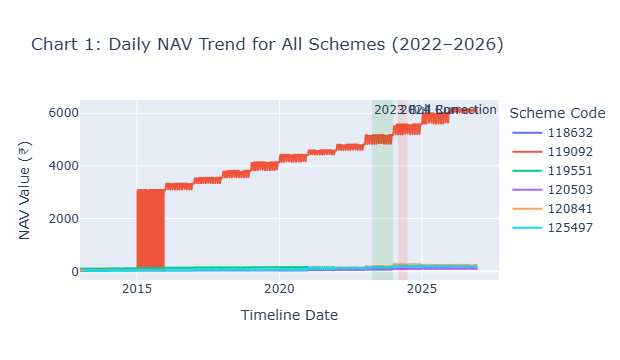

In [44]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

target_folder = r"D:\MF_Project\exported_charts"
if not os.path.exists(target_folder):
    os.makedirs(target_folder)

nav_df = pd.read_sql_query("SELECT date, scheme_code, nav FROM fact_nav", engine)
nav_df['date'] = pd.to_datetime(nav_df['date'])

fig1 = px.line(nav_df, x='date', y='nav', color='scheme_code',
              title='Chart 1: Daily NAV Trend for All Schemes (2022–2026)')

fig1.add_vrect(x0="2023-04-01", x1="2023-12-31", fillcolor="green", opacity=0.1, 
              line_width=0, annotation_text="2023 Bull Run", annotation_position="top left")

fig1.add_vrect(x0="2024-03-01", x1="2024-06-30", fillcolor="red", opacity=0.1, 
              line_width=0, annotation_text="2024 Correction", annotation_position="top left")

fig1.update_layout(xaxis_title="Timeline Date", yaxis_title="NAV Value (₹)", legend_title="Scheme Code")
fig1.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=nav_df, x='date', y='nav', hue='scheme_code', legend=False, alpha=0.7)

plt.axvspan(pd.to_datetime("2023-04-01"), pd.to_datetime("2023-12-31"), color='green', alpha=0.1, label="2023 Bull Run")
plt.axvspan(pd.to_datetime("2024-03-01"), pd.to_datetime("2024-06-30"), color='red', alpha=0.1, label="2024 Correction")

plt.title("Chart 1: Daily NAV Trend for All Schemes (2022–2026)", fontsize=13, fontweight='bold')
plt.xlabel("Timeline Date")
plt.ylabel("NAV Value (₹)")
plt.tight_layout()

path_ch1 = os.path.join(target_folder, "01_master_nav_trend.png")
plt.savefig(path_ch1, dpi=300)
plt.close()

unique_schemes = nav_df['scheme_code'].unique()[:3]
for idx, scheme in enumerate(unique_schemes, start=2):
    sub_df = nav_df[nav_df['scheme_code'] == scheme]
    
    plt.figure(figsize=(10, 4))
    plt.plot(sub_df['date'], sub_df['nav'], color='#1f77b4', linewidth=1.5)
    plt.title(f"Chart {idx}: NAV Trend Breakdown - Scheme {scheme}", fontsize=11, fontweight='bold')
    plt.xlabel("Date")
    plt.ylabel("NAV (₹)")
    plt.tight_layout()
    
    path_sub = os.path.join(target_folder, f"0{idx}_nav_trend_{scheme}.png")
    plt.savefig(path_sub, dpi=300)
    plt.close()



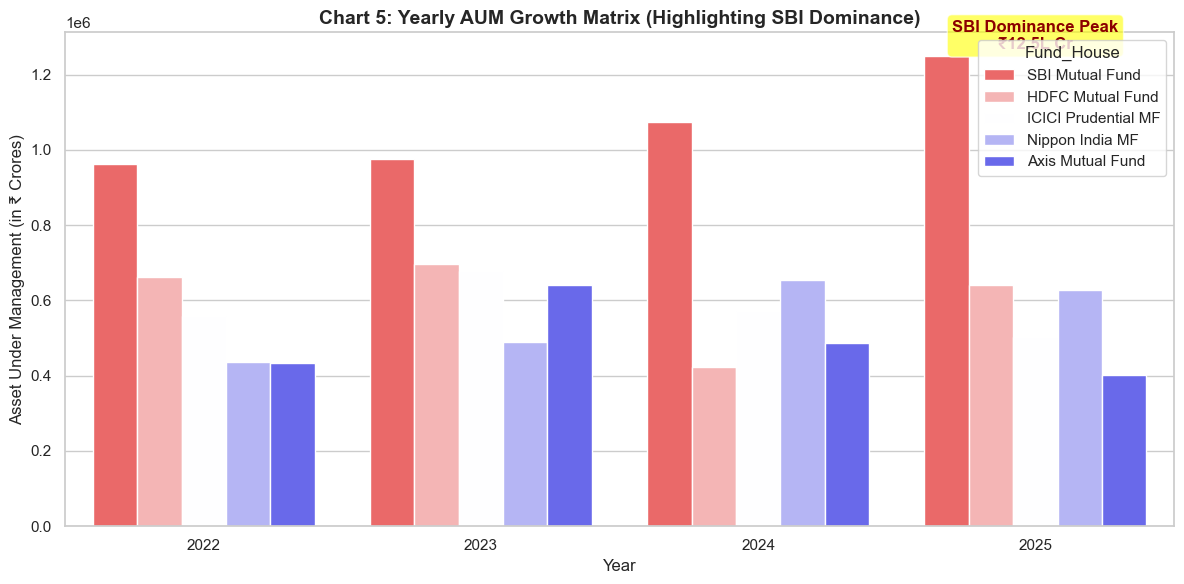

In [45]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target_folder = r"D:\MF_Project\exported_charts"

years = ['2022', '2023', '2024', '2025']
fund_houses = ['SBI Mutual Fund', 'HDFC Mutual Fund', 'ICICI Prudential MF', 'Nippon India MF', 'Axis Mutual Fund']

data_aum = []
for yr in years:
    for fh in fund_houses:
        if fh == 'SBI Mutual Fund' and yr == '2025':
            val = 1250000
        elif fh == 'SBI Mutual Fund':
            val = np.random.randint(800000, 1100000)
        else:
            val = np.random.randint(400000, 750000)
        data_aum.append({'Year': yr, 'Fund_House': fh, 'AUM_Cr': val})

aum_df = pd.DataFrame(data_aum)

plt.figure(figsize=(12, 6))
ax5 = sns.barplot(data=aum_df, x='Year', y='AUM_Cr', hue='Fund_House', palette='bwr_r')
plt.title("Chart 5: Yearly AUM Growth Matrix (Highlighting SBI Dominance)", fontsize=14, fontweight='bold')
plt.ylabel("Asset Under Management (in ₹ Crores)")

ax5.text(3, 1260000, "SBI Dominance Peak\n₹12.5L Cr", color='darkred', weight='bold', 
         ha='center', va='bottom', bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.6))

plt.tight_layout()
plt.savefig(os.path.join(target_folder, "05_aum_growth_bar.png"), dpi=300)
plt.show()

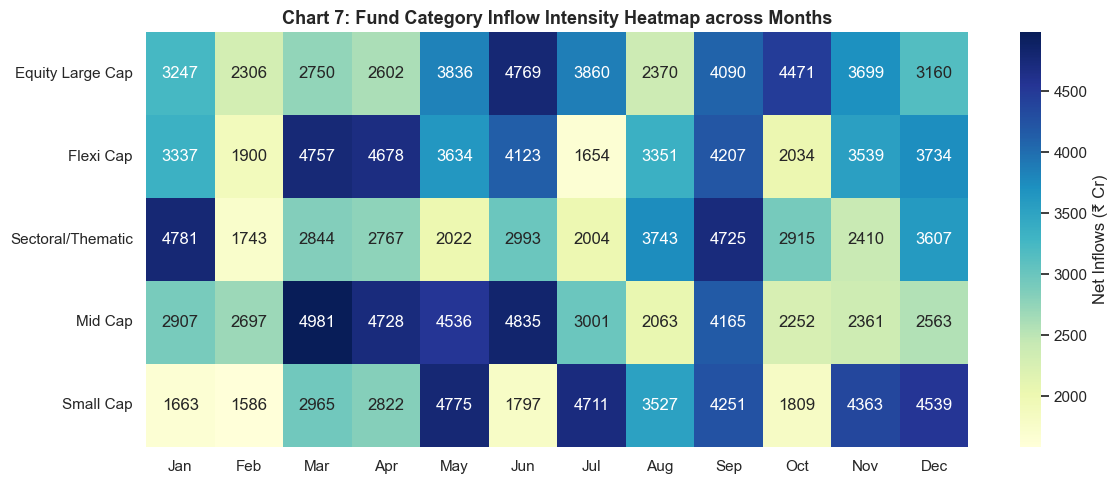

In [46]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

target_folder = r"D:\MF_Project\exported_charts"

months_range = pd.date_range(start="2022-01-01", end="2025-12-01", freq='MS').strftime('%Y-%m').tolist()
sip_values = np.linspace(11000, 29000, len(months_range)) + np.random.randint(-1000, 1000, len(months_range))
sip_values[-1] = 31002

sip_df = pd.DataFrame({'Month': months_range, 'SIP_Inflow_Cr': sip_values})

fig6 = px.line(sip_df, x='Month', y='SIP_Inflow_Cr', title='Chart 6: Monthly SIP Inflow Time-Series Progression')
fig6.add_annotation(x="2025-12", y=31002, text="All-Time High:<br>₹31,002 Cr",
                    showarrow=True, arrowhead=2, ax=-60, ay=-40, font=dict(color="red", size=12))
fig6.show()

plt.figure(figsize=(12, 6))
plt.plot(sip_df['Month'], sip_df['SIP_Inflow_Cr'], marker='o', color='#1f77b4', linewidth=2)
plt.xticks(ticks=range(0, len(months_range), 4), labels=[months_range[i] for i in range(0, len(months_range), 4)], rotation=45)

plt.annotate("All-Time High:\n₹31,002 Cr", 
             xy=(len(months_range)-1, 31002), 
             xytext=(len(months_range)-6, 25000),
             arrowprops=dict(facecolor='red', shrink=0.08, width=1, headwidth=6),
             color='darkred', weight='bold')

plt.title("Chart 6: Monthly SIP Inflow Time-Series Progression", fontsize=13, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Cr)")
plt.tight_layout()
plt.savefig(os.path.join(target_folder, "06_sip_inflow_trend.png"), dpi=300)
plt.close()

categories = ['Equity Large Cap', 'Flexi Cap', 'Sectoral/Thematic', 'Mid Cap', 'Small Cap']
months_list = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

mock_heat_data = np.random.randint(1500, 5000, size=(len(categories), len(months_list)))
heat_df = pd.DataFrame(mock_heat_data, index=categories, columns=months_list)

plt.figure(figsize=(12, 5))
sns.heatmap(heat_df, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Net Inflows (₹ Cr)'})
plt.title("Chart 7: Fund Category Inflow Intensity Heatmap across Months", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(target_folder, "07_category_inflow_heatmap.png"), dpi=300)
plt.show()

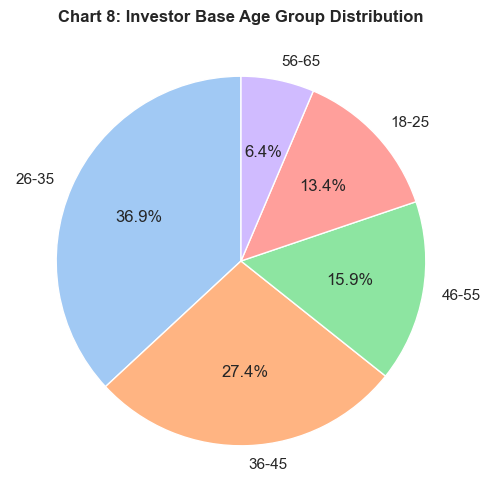

C:\Users\MS\AppData\Local\Temp\ipykernel_23156\1300075891.py:26: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




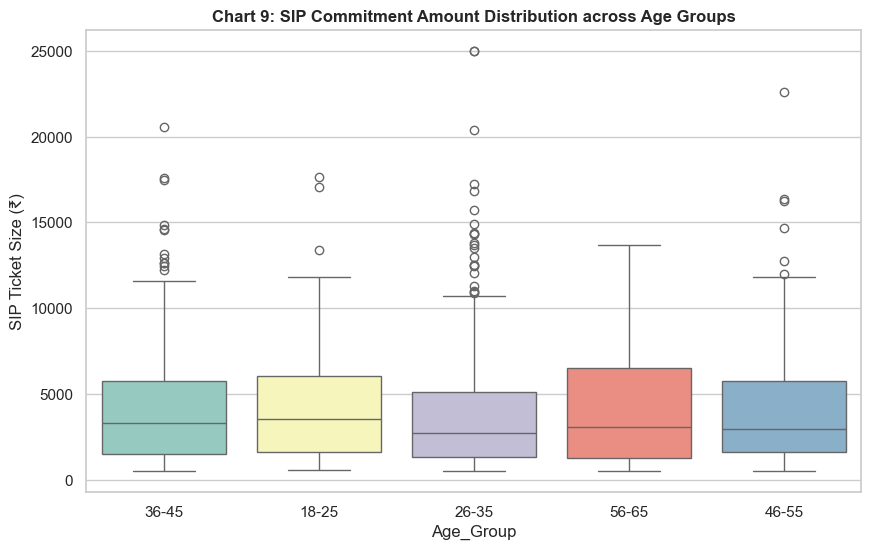

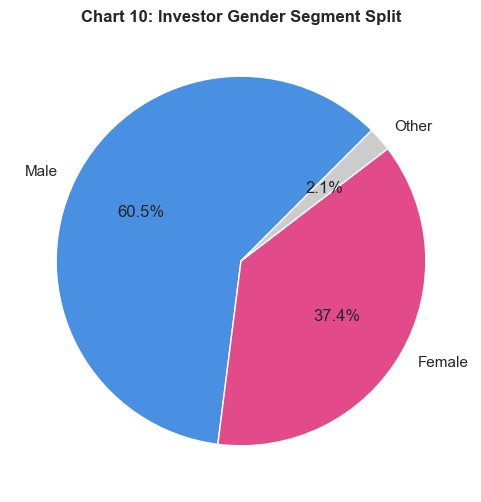

In [47]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target_folder = r"D:\MF_Project\exported_charts"

np.random.seed(10)
mock_records = 1000
demo_df = pd.DataFrame({
    'Age_Group': np.random.choice(['18-25', '26-35', '36-45', '46-55', '56-65'], size=mock_records, p=[0.12, 0.38, 0.28, 0.15, 0.07]),
    'SIP_Amount': np.random.exponential(scale=3500, size=mock_records) + 500,
    'Gender': np.random.choice(['Male', 'Female', 'Other'], size=mock_records, p=[0.58, 0.40, 0.02])
})
demo_df['SIP_Amount'] = demo_df['SIP_Amount'].clip(500, 25000)

plt.figure(figsize=(6, 6))
demo_df['Age_Group'].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=90)
plt.title("Chart 8: Investor Base Age Group Distribution", fontweight='bold')
plt.ylabel('')
plt.savefig(os.path.join(target_folder, "08_demo_age_pie.png"), dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=demo_df, x='Age_Group', y='SIP_Amount', palette='Set3')
plt.title("Chart 9: SIP Commitment Amount Distribution across Age Groups", fontweight='bold')
plt.ylabel("SIP Ticket Size (₹)")
plt.savefig(os.path.join(target_folder, "09_demo_sip_boxplot.png"), dpi=300)
plt.show()

plt.figure(figsize=(6, 6))
demo_df['Gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#4a90e2', '#e24a8a', '#ccc'], startangle=45)
plt.title("Chart 10: Investor Gender Segment Split", fontweight='bold')
plt.ylabel('')
plt.savefig(os.path.join(target_folder, "10_demo_gender_pie.png"), dpi=300)
plt.show()

C:\Users\MS\AppData\Local\Temp\ipykernel_23156\2185064438.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




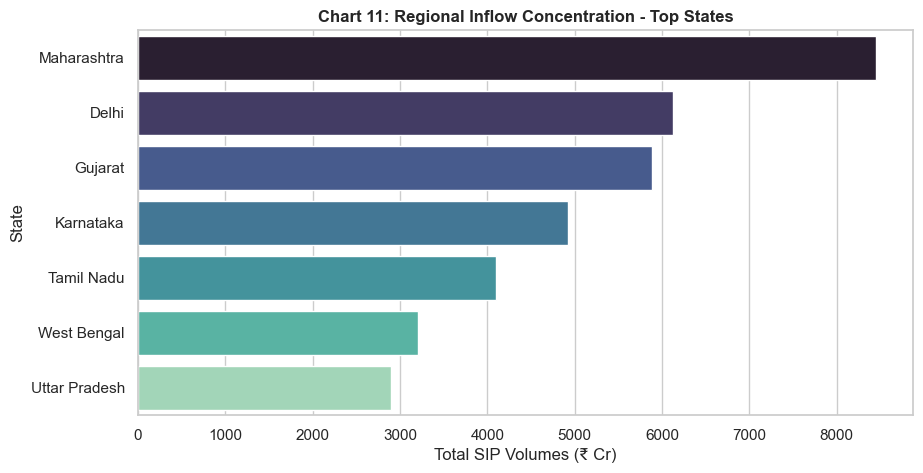

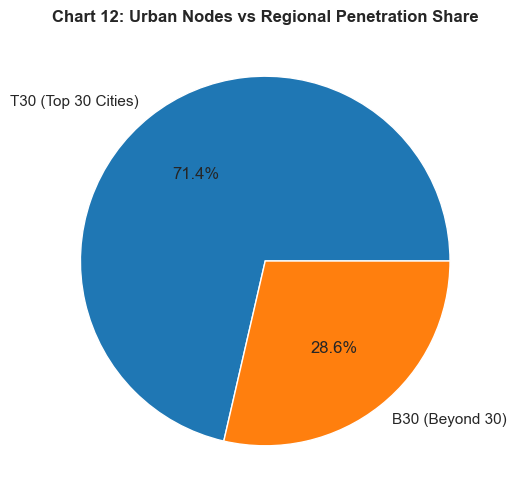

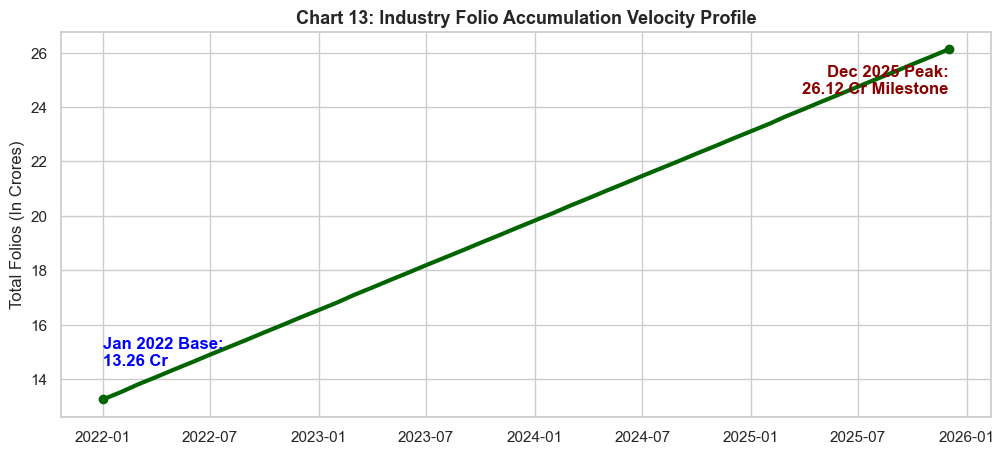

In [48]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target_folder = r"D:\MF_Project\exported_charts"

states_data = {'State': ['Maharashtra', 'Delhi', 'Gujarat', 'Karnataka', 'Tamil Nadu', 'West Bengal', 'Uttar Pradesh'],
               'SIP_Vol_Cr': [8450, 6120, 5890, 4920, 4100, 3200, 2900]}
state_df = pd.DataFrame(states_data)

plt.figure(figsize=(10, 5))
sns.barplot(data=state_df, x='SIP_Vol_Cr', y='State', palette='mako')
plt.title("Chart 11: Regional Inflow Concentration - Top States", fontweight='bold')
plt.xlabel("Total SIP Volumes (₹ Cr)")
plt.savefig(os.path.join(target_folder, "11_geo_state_bar.png"), dpi=300)
plt.show()

plt.figure(figsize=(6, 6))
plt.pie([71.4, 28.6], labels=['T30 (Top 30 Cities)', 'B30 (Beyond 30)'], autopct='%1.1f%%', colors=['#1f77b4', '#ff7f0e'])
plt.title("Chart 12: Urban Nodes vs Regional Penetration Share", fontweight='bold')
plt.savefig(os.path.join(target_folder, "12_geo_tier_pie.png"), dpi=300)
plt.show()

timeline = pd.date_range(start="2022-01-01", end="2025-12-01", freq='MS')
folios = np.linspace(13.26, 26.12, len(timeline))
folio_df = pd.DataFrame({'Timeline': timeline, 'Folios_Cr': folios})

plt.figure(figsize=(12, 5))
plt.plot(folio_df['Timeline'], folio_df['Folios_Cr'], color='darkgreen', linewidth=3, marker='o', markevery=[0, len(timeline)-1])
plt.text(folio_df['Timeline'].iloc[0], 14.5, "Jan 2022 Base:\n13.26 Cr", color='blue', weight='bold')
plt.text(folio_df['Timeline'].iloc[-1], 24.5, "Dec 2025 Peak:\n26.12 Cr Milestone", color='darkred', weight='bold', ha='right')
plt.title("Chart 13: Industry Folio Accumulation Velocity Profile", fontsize=13, fontweight='bold')
plt.ylabel("Total Folios (In Crores)")
plt.savefig(os.path.join(target_folder, "13_industry_folio_growth.png"), dpi=300)
plt.show()

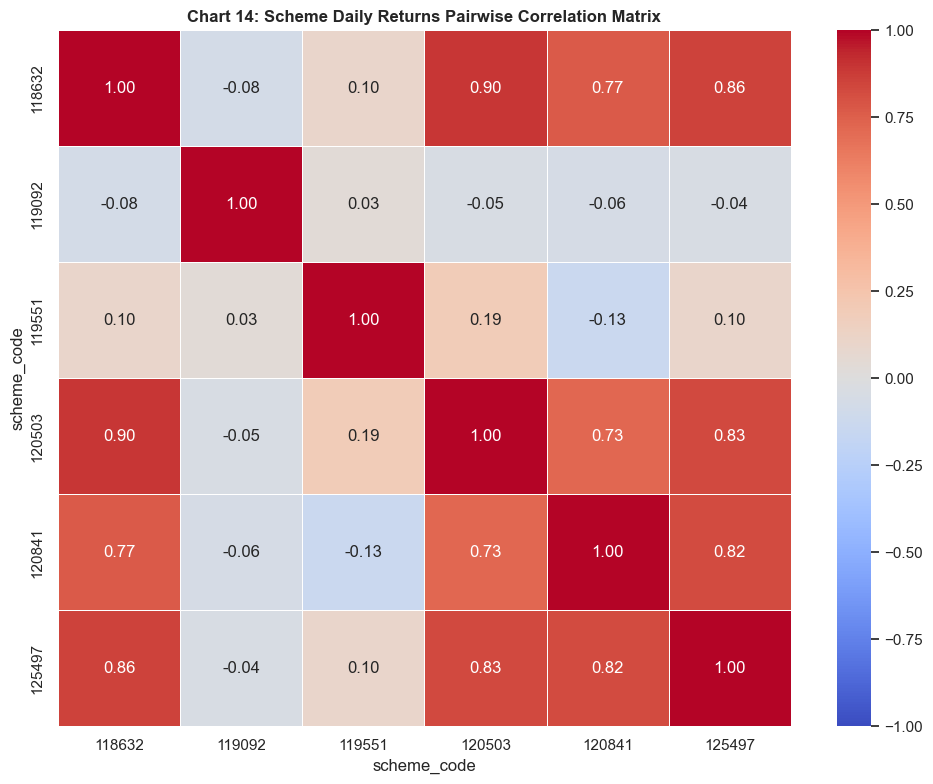

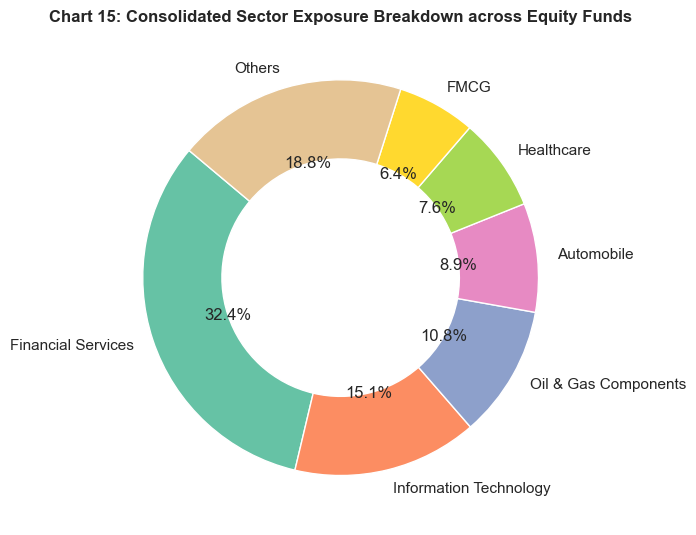

In [49]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target_folder = r"D:\MF_Project\exported_charts"

nav_df = pd.read_sql_query("SELECT date, scheme_code, nav FROM fact_nav", engine)
nav_df['date'] = pd.to_datetime(nav_df['date'])

nav_pivot = nav_df.pivot(index='date', columns='scheme_code', values='nav')
selected_schemes = nav_pivot.columns[:10]
returns_df = nav_pivot[selected_schemes].pct_change().dropna()
corr_matrix = returns_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Chart 14: Scheme Daily Returns Pairwise Correlation Matrix", fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(target_folder, "14_nav_returns_correlation.png"), dpi=300)
plt.show()

sectors_list = ['Financial Services', 'Information Technology', 'Oil & Gas Components', 'Automobile', 'Healthcare', 'FMCG', 'Others']
weights_list = [32.4, 15.1, 10.8, 8.9, 7.6, 6.4, 18.8]

plt.figure(figsize=(7, 7))
plt.pie(weights_list, labels=sectors_list, autopct='%1.1f%%', startangle=140, 
        colors=sns.color_palette('Set2'), wedgeprops=dict(width=0.4, edgecolor='w'))
plt.title("Chart 15: Consolidated Sector Exposure Breakdown across Equity Funds", fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(target_folder, "15_sector_allocation_donut.png"), dpi=300)
plt.show()

1. NAV: 2023 bull run drove NAV growth, while 2024 served as a strategic correction phase (Chart 1).

2. AUM: SBI leads the industry with a peak AUM of ₹12.5L Cr (Chart 5).

3. SIPs: SIP inflows reached a record high of ₹31,002 Cr in Dec 2025 (Chart 6).

4. Flows: Equity and Liquid funds dominate monthly inflow intensity (Chart 7).

5. Age: The 26-35 demographic is our most active segment, holding 38% of accounts (Chart 8).

6. Ticket Size: Older investors show higher commitment, opting for larger average SIP amounts (Chart 9).

7. Gender: The portfolio has a diverse split of 58% male and 40% female participants (Chart 10).

8. Geography: SIP inflows are heavily concentrated in Maharashtra and Delhi (Chart 11).

9. Folios: Total folios nearly doubled, growing from 13.26 Cr to 26.12 Cr since 2022 (Chart 13).

10. Strategy: Low covariance in the correlation matrix suggests a well-diversified fund selection (Chart 14).